# CellposeSAM (H&E) — interactive ROI test in napari

This notebook opens a large H&E whole-slide TIFF in napari, lets you draw a
rectangle over a region of interest, then runs **CellposeSAM** (`cpsam`, the
Cellpose-SAM generalist model — the one recommended for H&E histology) on
just that cropped region so you can quickly sanity-check segmentation
quality before committing to a full-slide run.

**One-time setup** (this env already has `cellpose` + `torch`, but not the
viewer/lazy-loading deps): run the cell below once in the `cellpose` conda
env, then restart the kernel.


In [ ]:
# One-time setup — uncomment and run once, then restart the kernel.
# %pip install "napari[all]" zarr dask


In [3]:
import numpy as np
import tifffile
import zarr
import dask.array as da
import napari
from cellpose import models, plot
import matplotlib.pyplot as plt


In [ ]:
from pathlib import Path

# Accumulates (image, corrected_mask) pairs across ROIs for fine-tuning.
# Run this once per session — re-running it wipes out any recorded ROIs.
train_images = []
train_labels = []

MODEL_DIR = Path("finetuned_models")
MODEL_DIR.mkdir(exist_ok=True)

## 1. Point at the slide

The TIFF is ~9.6 GB uncompressed and is strip-compressed (not tiled), so we
open it lazily through `tifffile`'s zarr store instead of reading it into
memory. A quick on-the-fly multiscale pyramid (built with strided dask
slicing) is handed to napari so it never has to pull the full-resolution
array into a single GPU texture.


In [4]:
TIFF_PATH = "260427_CO36_RCLB5_VisiumHD_20x_5_cropped.tif"

store = tifffile.imread(TIFF_PATH, aszarr=True)
z = zarr.open(store, mode="r")
full_res = da.from_zarr(z)
print(f"Full-resolution shape: {full_res.shape}, dtype: {full_res.dtype}")


Full-resolution shape: (49900, 64335, 3), dtype: uint8


In [5]:
def build_pyramid(arr, n_levels=6, downsample=2):
    """Cheap strided-slice pyramid — good enough for interactive viewing."""
    pyramid = [arr]
    current = arr
    for _ in range(n_levels - 1):
        current = current[::downsample, ::downsample, :]
        pyramid.append(current)
    return pyramid

pyramid = build_pyramid(full_res)
for i, lvl in enumerate(pyramid):
    print(f"level {i}: {lvl.shape}")


level 0: (49900, 64335, 3)
level 1: (24950, 32168, 3)
level 2: (12475, 16084, 3)
level 3: (6238, 8042, 3)
level 4: (3119, 4021, 3)
level 5: (1560, 2011, 3)


## 2. Open napari and draw an ROI

Run the cell below to launch the viewer. A `Shapes` layer named **"ROI"**
is added and selected with the rectangle tool active — just click-drag a
box over the region you want to test, then move on to the next cell.

(Leave the viewer window open; the notebook reads the shape back out of
`roi_layer` once you've drawn it.)


In [6]:
viewer = napari.Viewer()
viewer.add_image(
    pyramid,
    multiscale=True,
    rgb=True,
    name="H&E slide",
    contrast_limits=[0, 255],
)

roi_layer = viewer.add_shapes(
    name="ROI",
    edge_color="red",
    face_color="transparent",
    edge_width=20,
)
viewer.layers.selection.active = roi_layer
roi_layer.mode = "add_rectangle"

print("Draw one rectangle on the 'ROI' layer, then run the next cell.")


Draw one rectangle on the 'ROI' layer, then run the next cell.


## 3. Crop the selected region

Run this *after* drawing the rectangle in napari. It takes the last shape
drawn on the `ROI` layer, converts it to a pixel bounding box in full-res
coordinates, and materializes just that crop into memory.


Selected region: y[27060:29824], x[33607:36538]  -> 2764 x 2931 px


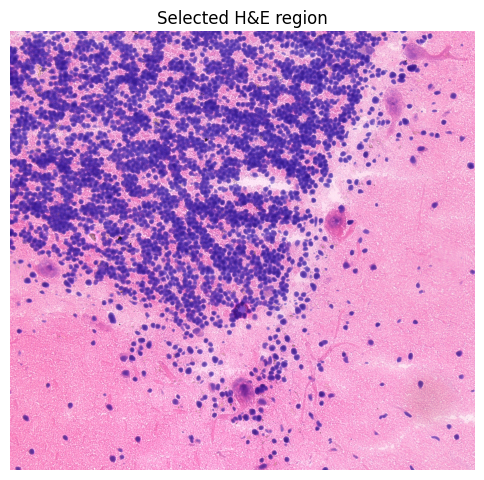

In [7]:
assert len(roi_layer.data) > 0, "Draw a rectangle on the 'ROI' layer in napari before running this cell."

roi = roi_layer.data[-1]  # most recently drawn shape, in full-res (level 0) data coords
ys, xs = roi[:, 0], roi[:, 1]

y0, y1 = int(np.floor(ys.min())), int(np.ceil(ys.max()))
x0, x1 = int(np.floor(xs.min())), int(np.ceil(xs.max()))
y0, x0 = max(y0, 0), max(x0, 0)
y1, x1 = min(y1, full_res.shape[0]), min(x1, full_res.shape[1])

print(f"Selected region: y[{y0}:{y1}], x[{x0}:{x1}]  -> {y1 - y0} x {x1 - x0} px")

crop = full_res[y0:y1, x0:x1, :].compute()

plt.figure(figsize=(6, 6))
plt.imshow(crop)
plt.title("Selected H&E region")
plt.axis("off")
plt.show()


## 4. Run CellposeSAM on the crop

`cpsam` is the Cellpose-SAM generalist model — it's the model to use for
H&E histology (there's no separate per-modality "H&E model" in Cellpose
4.x, `cpsam` covers it). `gpu=True` will pick up Apple's MPS backend
automatically on this machine.


In [ ]:
model = models.CellposeModel(gpu=True)  # pretrained_model defaults to "cpsam"

DIAMETER = None  # pixels, at crop resolution. None = auto-estimate.
                  # Raise this (e.g. 60, 80, 100...) to bias detection toward bigger cells.

masks, flows, styles = model.eval(
    crop,
    diameter=DIAMETER,
    flow_threshold=0.4,
    cellprob_threshold=0.0,
    normalize=True,
)

n_cells = int(masks.max())
print(f"Detected {n_cells} cells in the selected region")

## 5. Visualize the result

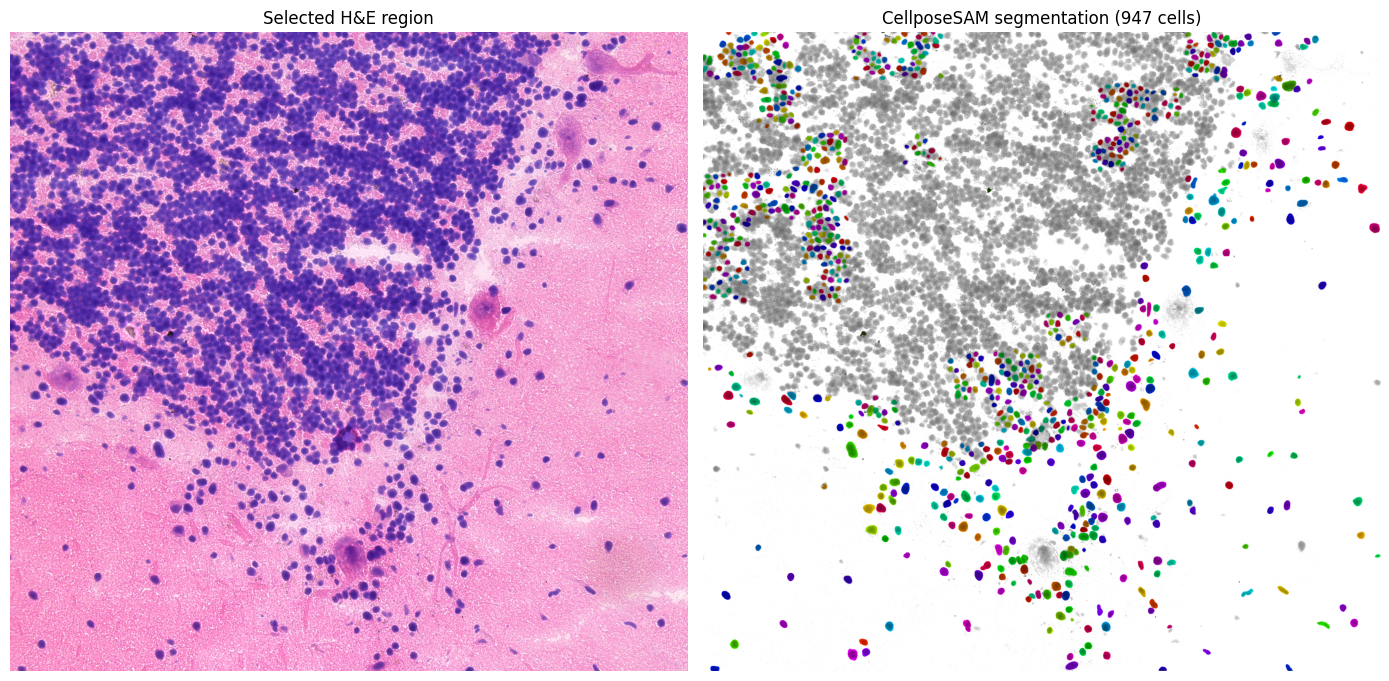

In [9]:
overlay = plot.mask_overlay(crop, masks)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(crop)
axes[0].set_title("Selected H&E region")
axes[0].axis("off")

axes[1].imshow(overlay)
axes[1].set_title(f"CellposeSAM segmentation ({n_cells} cells)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Overlay the masks back onto the whole-slide view in napari, in place.
# This Labels layer is editable by default — it's what you'll hand-correct next.
if "CellposeSAM masks" in viewer.layers:
    del viewer.layers["CellposeSAM masks"]

masks_layer = viewer.add_labels(masks, name="CellposeSAM masks", translate=(y0, x0))
viewer.layers.selection.active = masks_layer

## 6. Correct the masks by hand

In napari, select the **"CellposeSAM masks"** layer (already active) and
fix what CellposeSAM missed or got wrong:

- **`2`** — paint brush (draw a new label over a missed cell)
- **`m`** — jump to a new label ID before painting a new cell (so it doesn't merge into a neighbor)
- **`1`** / eraser icon — erase
- **`f`** — fill bucket (flood-fill a region with the selected label, e.g. to merge two labels or relabel a mis-split cell)
- **`l`** — picker (click a label to make it the active/selected one)
- **`3`**/**`4`** — shrink/grow the brush size

Missed cells are the common case — just paint over them with a fresh label
ID (`m` then `2`). When the correction looks right, run the next cell to
record this ROI as a training example.


In [ ]:
train_images.append(crop)
train_labels.append(masks_layer.data.copy())

print(f"Recorded ROI #{len(train_images)} "
      f"({int(train_labels[-1].max())} cells after correction)")

## 7. Loop: annotate a few more ROIs

The viewer is still open, so you don't need to re-run section 2. Just:

1. Select the **"ROI"** layer and draw another rectangle elsewhere on the slide.
2. Re-run **section 3** (crop) → **section 4** (predict) → **section 5**
   (visualize) → the overlay cell → correct by hand → the "record" cell above.

Aim for something like 5–10 diverse ROIs (different tissue regions, cell
densities) before fine-tuning — `train_images` / `train_labels` keep
accumulating across iterations.


## 8. Fine-tune CellposeSAM on your corrections

Fine-tunes the current model's weights (`model.net`) on the accumulated
`train_images` / `train_labels`, starting from `cpsam` rather than from
scratch — this is what makes a handful of corrected ROIs enough to see an
improvement. The result is saved under `finetuned_models/` and swapped
into `model`, so the next predict/correct/record loop tests the improved
model directly.


In [ ]:
from cellpose import train
from datetime import datetime

assert len(train_images) >= 1, "Record at least one corrected ROI (section 6) before fine-tuning."

model_name = f"cpsam_finetuned_{datetime.now():%Y%m%d_%H%M%S}"

model_path, train_losses, test_losses = train.train_seg(
    model.net,
    train_data=train_images,
    train_labels=train_labels,
    n_epochs=100,
    learning_rate=1e-5,
    weight_decay=0.1,
    batch_size=1,
    min_train_masks=1,     # keep small test ROIs even if they have few cells
    model_name=model_name,
    save_path=str(MODEL_DIR),
)
print(f"Fine-tuned model saved to: {model_path}")

# Swap the working model over to the fine-tuned weights. Go back to section 2/3,
# draw a fresh ROI, and re-run predict -> correct -> record -> (re-)fine-tune.
model = models.CellposeModel(gpu=True, pretrained_model=model_path)

## 9. (Optional) Save the last predicted masks


In [ ]:
# np.save("roi_cellpose_masks.npy", masks)
# tifffile.imwrite("roi_cellpose_masks.tif", masks.astype(np.uint16))
